
TRAIN DATASET EDA

Class Distribution:
closed: 58470 images (47.47%)
open: 64697 images (52.53%)

Total Images: 123167
Balance Ratio (max/min): 1.11:1


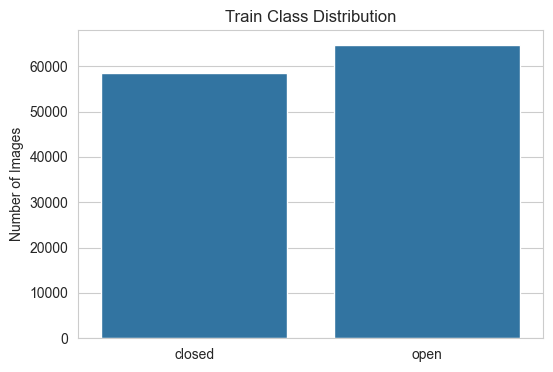

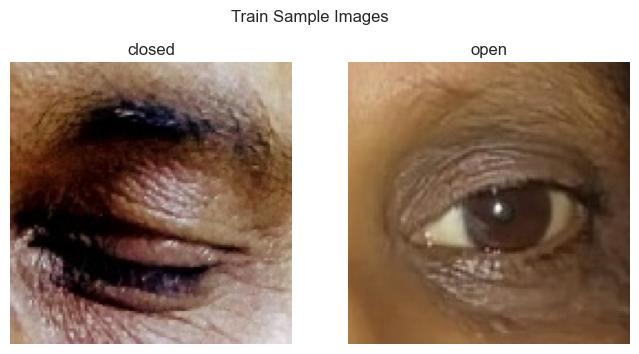


Image Dimensions:
Width  -> min:128, max:128, mean:128.0
Height -> min:128, max:128, mean:128.0
Aspect Ratio Mean: 1.000


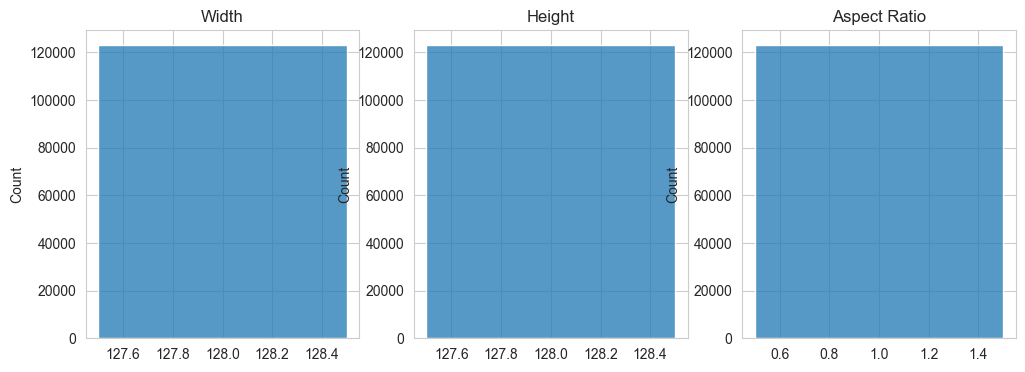


Brightness & Contrast:
Mean Brightness: 102.71
Mean Contrast: 39.43
Too Dark Images (<30): 1965
Too Bright Images (>220): 24


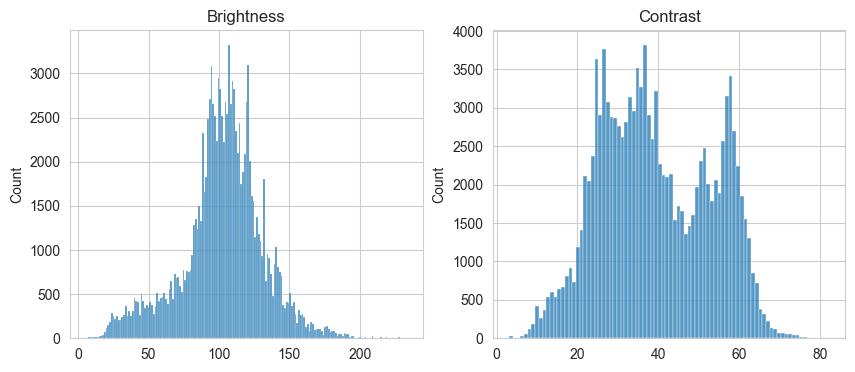


Color Channels Found: {3}

Corrupted Images Found: 0
Duplicate Images Found: 65801

------------------------------------------------------------
TRAIN SUMMARY
------------------------------------------------------------
Total images: 123167
Balanced dataset: True
Consistent image size: True
Corrupted images: 0
Duplicate images: 65801
------------------------------------------------------------

VALIDATION DATASET EDA

Class Distribution:
closed: 14618 images (47.47%)
open: 16175 images (52.53%)

Total Images: 30793
Balance Ratio (max/min): 1.11:1


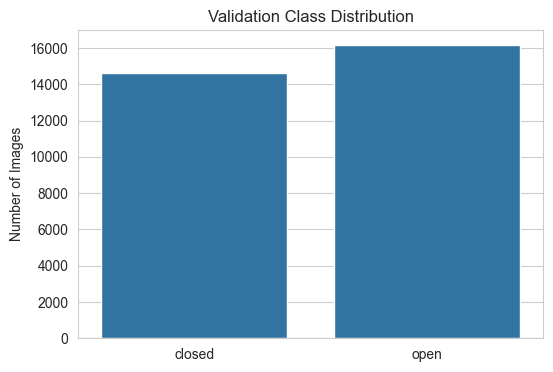

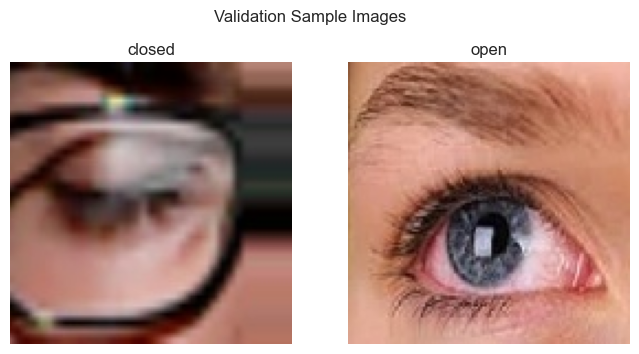


Image Dimensions:
Width  -> min:128, max:128, mean:128.0
Height -> min:128, max:128, mean:128.0
Aspect Ratio Mean: 1.000


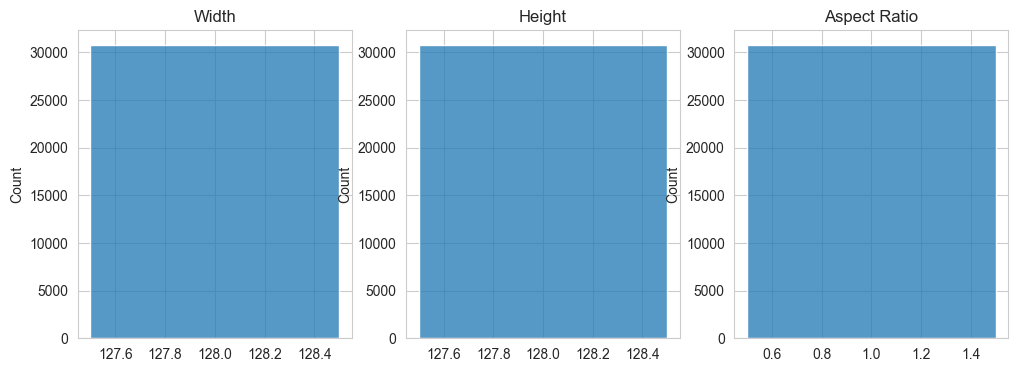


Brightness & Contrast:
Mean Brightness: 102.77
Mean Contrast: 39.28
Too Dark Images (<30): 500
Too Bright Images (>220): 7


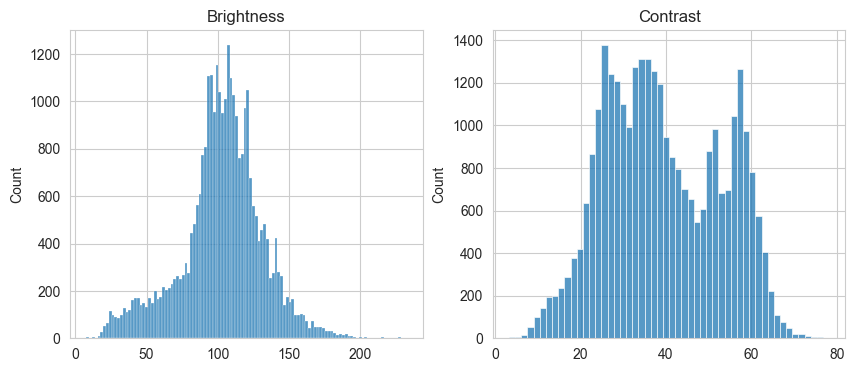


Color Channels Found: {3}

Corrupted Images Found: 0
Duplicate Images Found: 13839

------------------------------------------------------------
VALIDATION SUMMARY
------------------------------------------------------------
Total images: 30793
Balanced dataset: True
Consistent image size: True
Corrupted images: 0
Duplicate images: 13839
------------------------------------------------------------


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
import hashlib

sns.set_style("whitegrid")

# ==========================================
# DATASET PATHS
# ==========================================
train_path = "F:/Split/train"
val_path   = "F:/Split/val"

splits = {
    "Train": train_path,
    "Validation": val_path
}

# ==========================================
# HELPER FUNCTIONS
# ==========================================
def get_classes(path):
    return [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]

def count_images(path):
    counts = {}
    for cls in get_classes(path):
        cls_path = os.path.join(path, cls)
        counts[cls] = len(os.listdir(cls_path))
    return counts

def image_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

# ==========================================
# MAIN EDA LOOP (TRAIN & VALIDATION SEPARATE)
# ==========================================
for split_name, split_path in splits.items():

    print("\n" + "="*70)
    print(f"{split_name.upper()} DATASET EDA")
    print("="*70)

    classes = get_classes(split_path)

    # ------------------------------------------
    # 1. CLASS DISTRIBUTION & DATA BALANCE
    # ------------------------------------------
    counts = count_images(split_path)
    total = sum(counts.values())

    print("\nClass Distribution:")
    for cls, v in counts.items():
        print(f"{cls}: {v} images ({(v/total)*100:.2f}%)")

    balance_ratio = round(max(counts.values()) / min(counts.values()), 2)
    print(f"\nTotal Images: {total}")
    print(f"Balance Ratio (max/min): {balance_ratio}:1")

    plt.figure(figsize=(6,4))
    sns.barplot(x=list(counts.keys()), y=list(counts.values()))
    plt.title(f"{split_name} Class Distribution")
    plt.ylabel("Number of Images")
    plt.show()

    # ------------------------------------------
    # 2. SAMPLE IMAGE VISUALIZATION
    # ------------------------------------------
    plt.figure(figsize=(8,4))
    for i, cls in enumerate(classes):
        img_folder = os.path.join(split_path, cls)
        img_name = os.listdir(img_folder)[0]
        img = Image.open(os.path.join(img_folder, img_name))
        plt.subplot(1, len(classes), i+1)
        plt.imshow(img)
        plt.title(f"{cls}")
        plt.axis("off")
    plt.suptitle(f"{split_name} Sample Images")
    plt.show()

    # ------------------------------------------
    # 3. IMAGE SIZE & ASPECT RATIO
    # ------------------------------------------
    widths, heights = [], []

    for cls in classes:
        folder = os.path.join(split_path, cls)
        for img_name in os.listdir(folder):
            try:
                img = Image.open(os.path.join(folder, img_name))
                w, h = img.size
                widths.append(w)
                heights.append(h)
            except:
                pass

    aspect_ratios = [w/h for w, h in zip(widths, heights)]

    print("\nImage Dimensions:")
    print(f"Width  -> min:{min(widths)}, max:{max(widths)}, mean:{np.mean(widths):.1f}")
    print(f"Height -> min:{min(heights)}, max:{max(heights)}, mean:{np.mean(heights):.1f}")
    print(f"Aspect Ratio Mean: {np.mean(aspect_ratios):.3f}")

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); sns.histplot(widths); plt.title("Width")
    plt.subplot(1,3,2); sns.histplot(heights); plt.title("Height")
    plt.subplot(1,3,3); sns.histplot(aspect_ratios); plt.title("Aspect Ratio")
    plt.show()

    # ------------------------------------------
    # 4. BRIGHTNESS & CONTRAST ANALYSIS
    # ------------------------------------------
    brightness, contrast = [], []

    for cls in classes:
        folder = os.path.join(split_path, cls)
        for img_name in os.listdir(folder):
            img = cv2.imread(os.path.join(folder, img_name), cv2.IMREAD_GRAYSCALE)
            if img is not None:
                brightness.append(np.mean(img))
                contrast.append(np.std(img))

    brightness = np.array(brightness)

    print("\nBrightness & Contrast:")
    print(f"Mean Brightness: {brightness.mean():.2f}")
    print(f"Mean Contrast: {np.mean(contrast):.2f}")
    print(f"Too Dark Images (<30): {np.sum(brightness < 30)}")
    print(f"Too Bright Images (>220): {np.sum(brightness > 220)}")

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); sns.histplot(brightness); plt.title("Brightness")
    plt.subplot(1,2,2); sns.histplot(contrast); plt.title("Contrast")
    plt.show()

    # ------------------------------------------
    # 5. COLOR CHANNEL CHECK
    # ------------------------------------------
    channels = set()

    for cls in classes:
        folder = os.path.join(split_path, cls)
        for img_name in os.listdir(folder)[:50]:
            img = cv2.imread(os.path.join(folder, img_name))
            if img is not None:
                channels.add(1 if len(img.shape)==2 else img.shape[2])

    print("\nColor Channels Found:", channels)

    # ------------------------------------------
    # 6. CORRUPTED IMAGE CHECK
    # ------------------------------------------
    corrupted = []

    for cls in classes:
        folder = os.path.join(split_path, cls)
        for img_name in os.listdir(folder):
            try:
                Image.open(os.path.join(folder, img_name)).verify()
            except:
                corrupted.append(os.path.join(folder, img_name))

    print(f"\nCorrupted Images Found: {len(corrupted)}")

    # ------------------------------------------
    # 7. DUPLICATE IMAGE CHECK (HASH BASED)
    # ------------------------------------------
    hashes = {}
    duplicates = []

    for cls in classes:
        folder = os.path.join(split_path, cls)
        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            try:
                h = image_hash(img_path)
                if h in hashes:
                    duplicates.append((img_path, hashes[h]))
                else:
                    hashes[h] = img_path
            except:
                pass

    print(f"Duplicate Images Found: {len(duplicates)}")

    # ------------------------------------------
    # 8. FINAL SUMMARY
    # ------------------------------------------
    print("\n" + "-"*60)
    print(f"{split_name.upper()} SUMMARY")
    print("-"*60)
    print(f"Total images: {total}")
    print(f"Balanced dataset: {balance_ratio <= 1.5}")
    print(f"Consistent image size: {len(set(widths))==1 and len(set(heights))==1}")
    print(f"Corrupted images: {len(corrupted)}")
    print(f"Duplicate images: {len(duplicates)}")
    print("-"*60)
